In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib inline
import seaborn as sns
from IPython.display import HTML
from klassen import City, distanz, neighbour, distanz_km

In [13]:
df = pd.read_csv('msg_standorte_deutschland.csv')
#display (df)

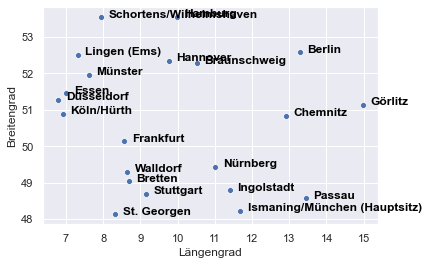

In [14]:
sns.set() 
ax = sns.scatterplot(y="Breitengrad", x="Längengrad", data=df)
for line in range(0,df.shape[0]):
     ax.text(df.Längengrad[line]+0.2, df.Breitengrad[line], df.msg_Standort[line], horizontalalignment='left', size='medium', color='black', weight='semibold')

Die Daten aus der Tabelle (Pandas Datenframe) werden genutzt um für jede Stadt eine Klasse City zu erzeugen, die die Kooridinaten und Nummer und Name der Stadt enthält.

In [15]:
cities = []

for row in df.itertuples():
    new = City(row.Längengrad, row.Breitengrad, row.Nummer, row.msg_Standort)
    cities.append(new)

# Nearest Neighbour Approach

Die Tour beginnt an der Start-Stadt, von da aus wird bezogen auf die Distanz der nächste Nachbar ausgewält und zur Tour hinzugefügt. Anschließend wird von da aus nach dem nächsten Nachbar gesucht usw. bis alle Städte besucht wurden. 

Dabei handelt es sich aber nur um eine Annäherung an die vermutlich beste Lösung. 

In [16]:
tour = [cities[0]]
unbesucht = cities[1:]

#solange noch unbesuchte Städte vorhanden sind:
while unbesucht:
    #für die letzte Stadt in der Liste tour wird der nächste Nachbar berechnet
    result = neighbour(tour[-1], unbesucht)
    tour.append(result)
    #da die Stadt somit besucht wurde, wird sie aus der Liste unbesucht gelöscht
    unbesucht.remove(result)

#die Reise zurück zum Start hinzufügen
tour.append(cities[0])



Ausgabe aller Standorte in der Reihenfolge in der sie besucht werden: 

In [17]:
for c in tour:
    print("* " + c.name)


* Ismaning/München (Hauptsitz)
* Ingolstadt
* Nürnberg
* Stuttgart
* Bretten
* Walldorf
* Frankfurt
* Köln/Hürth
* Düsseldorf
* Essen
* Münster
* Lingen (Ems)
* Schortens/Wilhelmshaven
* Hamburg
* Hannover
* Braunschweig
* Berlin
* Chemnitz
* Görlitz
* Passau
* St. Georgen
* Ismaning/München (Hauptsitz)


In [19]:
#Entfernung in km berechnen
strecke = 0
for i in range (0, len(tour)-1):
    strecke += distanz_km(tour[i], tour[i+1])
print ("Zurückgelegte Strecke: " + str(round(strecke,2)) + " Kilometer")

Zurückgelegte Strecke: 2743.83 Kilometer


# Animierter Plot der zurückgelegten Strecke

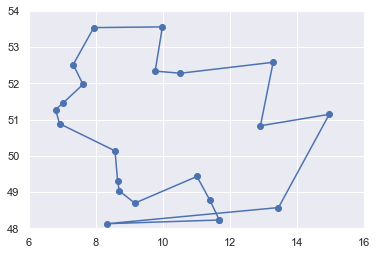

In [9]:
# Figure für den Plot erzeugen
fig, ax = plt.subplots()
ax.set_xlim((6,16))
ax.set_ylim((48,54))

line, = ax.plot([], [], "bo-")

# Hintergrund für jeden Frame ploten mit der init-Funktion
def init():
    line.set_data([], [])
    return (line,)

# Animate function wird für jeden Frame aufgerufen und ein neuer Punkt hinzugefügt
def animate(i):
    xdata = [p.x for p in tour[:i]]
    ydata = [p.y for p in tour[:i]]
    line.set_data(xdata, ydata)
    return (line,)

# Animation aufrufen (blit=True means only re-draw the parts that have changed)
anim = FuncAnimation(fig, animate, init_func=init, frames=23, interval=200, blit=True, repeat=False)

#Ausgabe im Juypter Notebook mit HTML5
HTML(anim.to_html5_video())